In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt

In [11]:
# ---------------------- 超参数设置 ----------------------
batch_size = 128
latent_dim = 20       # z隐向量维度
epochs = 20
lr = 1e-3
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


In [13]:
# ---------------------- MNIST数据集加载 ----------------------
transform = transforms.Compose([
    transforms.ToTensor(),  # [0,1]
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [14]:
# ---------------------- VAE模型定义 ----------------------
class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=20):
        super().__init__()
        # Encoder: 784 -> 隐空间 mu, log_var
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 2 * latent_dim)   # 输出 mu + log_var
        )

        # Decoder: z -> 784 重建图片
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, input_dim),
            nn.Sigmoid()   # MNIST像素0~1
        )

    def reparameterize(self, mu, log_var):
        """重参数技巧：z = mu + sigma * epsilon"""
        sigma = torch.exp(0.5 * log_var)
        eps = torch.randn_like(sigma)
        return mu + sigma * eps

    def forward(self, x):
        # x: [B,784]
        enc_out = self.encoder(x)
        mu, log_var = torch.chunk(enc_out, 2, dim=1)  # 拆分成均值、对数方差
        z = self.reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

model = VAE(input_dim=784, latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)


In [15]:
# ---------------------- ELBO损失函数 ----------------------
def loss_function(x_recon, x, mu, log_var):
    # 重建损失：MSE / BCE都可以，MNIST常用BCE
    recon_loss = nn.functional.binary_cross_entropy(x_recon, x, reduction='sum')
    # KL散度：q(z|x) vs N(0,I)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss


In [16]:
# ---------------------- 训练循环 ----------------------
print(f"using device: {device}")
model.train()
for epoch in range(epochs):
    total_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.view(-1, 784).to(device) # flatten 28*28=784
        optimizer.zero_grad()

        x_recon, mu, log_var = model(imgs)
        loss, recon_l, kl_l = loss_function(x_recon, imgs, mu, log_var)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}]  Avg Loss:{avg_loss:.2f}")


using device: mps
Epoch [1/20]  Avg Loss:164.31
Epoch [2/20]  Avg Loss:121.01
Epoch [3/20]  Avg Loss:114.22
Epoch [4/20]  Avg Loss:111.31
Epoch [5/20]  Avg Loss:109.62
Epoch [6/20]  Avg Loss:108.45
Epoch [7/20]  Avg Loss:107.66
Epoch [8/20]  Avg Loss:107.00
Epoch [9/20]  Avg Loss:106.47
Epoch [10/20]  Avg Loss:106.08
Epoch [11/20]  Avg Loss:105.69
Epoch [12/20]  Avg Loss:105.41
Epoch [13/20]  Avg Loss:105.13
Epoch [14/20]  Avg Loss:104.92
Epoch [15/20]  Avg Loss:104.66
Epoch [16/20]  Avg Loss:104.44
Epoch [17/20]  Avg Loss:104.27
Epoch [18/20]  Avg Loss:104.13
Epoch [19/20]  Avg Loss:103.98
Epoch [20/20]  Avg Loss:103.82


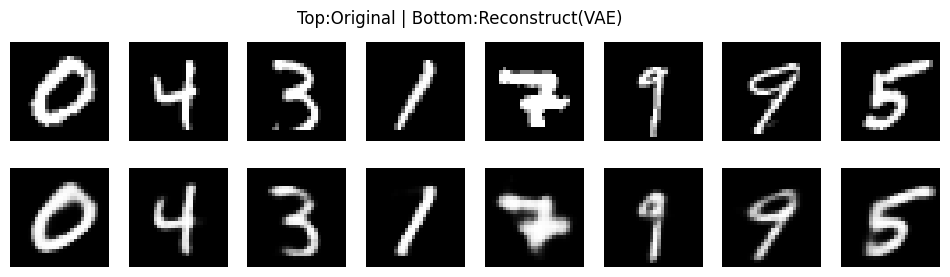

In [17]:
# ===================== 实验1：重建图片（训练阶段的行为） =====================
model.eval()
with torch.no_grad():
    imgs, _ = next(iter(train_loader))
    imgs_flat = imgs.view(-1,784).to(device)
    recon, _, _ = model(imgs_flat)

# 画原图 vs 重建图
n_show = 8
plt.figure(figsize=(12,3))
for i in range(n_show):
    # 原图
    ax = plt.subplot(2, n_show, i+1)
    plt.imshow(imgs[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    # 重建
    ax = plt.subplot(2, n_show, i+1+n_show)
    plt.imshow(recon[i].view(28,28).cpu(), cmap="gray")
    plt.axis("off")
plt.suptitle("Top:Original | Bottom:Reconstruct(VAE)")
plt.show()

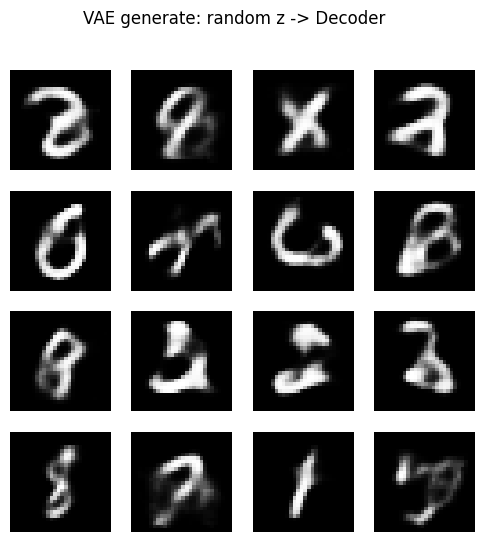

In [18]:
# ===================== 实验2：VAE生成【生成阶段，不需要Encoder输入图片】 =====================
# 直接从标准高斯采样z，只跑Decoder，CS231n重点
with torch.no_grad():
    # 随机采样z ~ N(0,I)
    sample_z = torch.randn(16, latent_dim).to(device)
    gen_imgs = model.decoder(sample_z) # 只用Decoder！！
    gen_imgs = gen_imgs.view(-1, 28,28).cpu()

plt.figure(figsize=(6,6))
for idx in range(16):
    plt.subplot(4,4,idx+1)
    plt.imshow(gen_imgs[idx], cmap="gray")
    plt.axis("off")
plt.suptitle("VAE generate: random z -> Decoder")
plt.show()



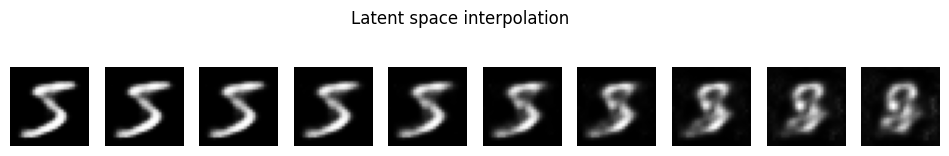

In [19]:
# ===================== 实验3：隐空间插值，两个数字之间平滑过渡 =====================
with torch.no_grad():
    # 取两张图片，得到它们的mu（确定性特征，不用采样z）
    img1, _ = train_dataset[0]
    img2, _ = train_dataset[1]

    h1 = img1.view(1,784).to(device)
    h2 = img2.view(1,784).to(device)

    mu1,_ = torch.chunk(model.encoder(h1),2,dim=1)
    mu2,_ = torch.chunk(model.encoder(h2),2,dim=1)

    # 在mu1与mu2之间插值
    interp_imgs = []
    for alpha in torch.linspace(0,1,10):
        z_interp = (1-alpha)*mu1 + alpha*mu2
        img_interp = model.decoder(z_interp)
        interp_imgs.append(img_interp.view(28,28).cpu())

plt.figure(figsize=(12,2))
for i, im in enumerate(interp_imgs):
    plt.subplot(1,10,i+1)
    plt.imshow(im, cmap="gray")
    plt.axis("off")
plt.suptitle("Latent space interpolation")
plt.show()
